In [ ]:
import cv2
import matplotlib.pyplot as plt
from src.preprocessing.preprocess import Preprocessing
import json 

In [2]:
# load config:
try:
    with open("config.json", "r", encoding="utf-8") as file:
        loaded_config = json.load(file)
        print("Config successfully loaded!")
except FileNotFoundError:
    print("Error: config.json not found. Falling back to default settings.")
    loaded_config = {}
except json.JSONDecodeError:
    print("Error: Invalid JSON format in config.json. Please check your syntax.")
    loaded_config = {}

Config successfully loaded!


In [8]:
pipeline = Preprocessing(config=loaded_config)
    
image_path = "data\\input\\testcase1_skew180.png"


--- Pipeline Results ---
Metadata: {'status': 'success', 'is_blank': False, 'blank_score': 0.9808031241477567, 'comment': 'rf_model (score=0.0192)', 'qr_codes': []}


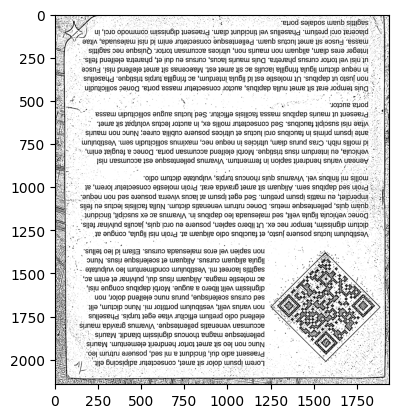

In [9]:
test_image = cv2.imread(image_path)

if test_image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # processed_image, meta_data = pipeline._process(test_image)
    result = pipeline._process(test_image)
    processed_image = result.image
    meta_data = result.metadata
    print("\n--- Pipeline Results ---")
    print(f"Metadata: {meta_data}")
    
plt.imshow(cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB))
plt.show()

In [10]:
print(result)

IMAGE
  size     : 1937 x 2143
  channels : 1
  dtype    : uint8

METADATA
  status     : success
  is_blank   : False
  confidence : 0.9808
  qr_count   : 0


In [11]:
from pyzbar import pyzbar
decoded_objects = pyzbar.decode(test_image)

In [12]:
from src.preprocessing.rotate import RotationDetector

tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

detector = RotationDetector(tesseract_path = tesseract_path)
angle = detector.detect(test_image)
print(f"Detected rotation angle: {angle} degrees")

Detected rotation angle: RotationResult(angle=180.0, confidence=18.28, script='Latin') degrees
